In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import joblib

In [24]:
X_train = pd.read_csv('../data/train_processed.csv')
X_test = pd.read_csv('../data/test_processed.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
test_ids = pd.read_csv('../data/test_ids.csv').squeeze()

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5-fold cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kf))
    return rmse

print("Scaling done. X_train_scaled shape:", X_train_scaled.shape)

Scaling done. X_train_scaled shape: (1458, 230)


In [26]:
ridge = Ridge(alpha=1.0, random_state=42)
lasso = Lasso(alpha=0.001, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)

ridge_scores = rmse_cv(ridge, X_train_scaled, y_train)
lasso_scores = rmse_cv(lasso, X_train_scaled, y_train)
gbr_scores = rmse_cv(gbr, X_train_scaled, y_train)

print(f"Ridge   RMSE: {ridge_scores.mean():.4f} (+/- {ridge_scores.std():.4f})")
print(f"Lasso   RMSE: {lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")
print(f"GBR     RMSE: {gbr_scores.mean():.4f} (+/- {gbr_scores.std():.4f})")

c:\Users\satya\Documents\house-price-predictor\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.548613e-02, tolerance: 1.886e-02
  model = cd_fast.enet_coordinate_descent(


Ridge   RMSE: 0.1289 (+/- 0.0141)
Lasso   RMSE: 0.1191 (+/- 0.0092)
GBR     RMSE: 0.1253 (+/- 0.0055)


In [27]:
lasso = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso_scores = rmse_cv(lasso, X_train_scaled, y_train)
print(f"Lasso   RMSE: {lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")

Lasso   RMSE: 0.1191 (+/- 0.0092)


In [28]:
ridge_params = {'alpha': [0.1, 1, 5, 10, 15, 20, 30, 50, 75, 100]}

ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_params,
                           scoring='neg_mean_squared_error', cv=kf)
ridge_grid.fit(X_train_scaled, y_train)

best_ridge_alpha = ridge_grid.best_params_['alpha']
best_ridge_rmse = np.sqrt(-ridge_grid.best_score_)

print(f"Best Ridge alpha: {best_ridge_alpha}")
print(f"Best Ridge RMSE: {best_ridge_rmse:.4f}")

Best Ridge alpha: 100
Best Ridge RMSE: 0.1205


In [29]:
ridge_params = {'alpha': [50, 75, 100, 150, 200, 300, 500, 750, 1000]}

ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_params,
                           scoring='neg_mean_squared_error', cv=kf)
ridge_grid.fit(X_train_scaled, y_train)

best_ridge_alpha = ridge_grid.best_params_['alpha']
best_ridge_rmse = np.sqrt(-ridge_grid.best_score_)

print(f"Best Ridge alpha: {best_ridge_alpha}")
print(f"Best Ridge RMSE: {best_ridge_rmse:.4f}")

Best Ridge alpha: 200
Best Ridge RMSE: 0.1196


In [30]:
best_ridge = Ridge(alpha=best_ridge_alpha, random_state=42)
best_ridge.fit(X_train_scaled, y_train)

print("Final Ridge model trained with alpha =", best_ridge_alpha)

Final Ridge model trained with alpha = 200


In [31]:
lasso_params = {'alpha': [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.003, 0.005, 0.01]}

lasso_grid = GridSearchCV(Lasso(random_state=42, max_iter=10000), lasso_params,
                           scoring='neg_mean_squared_error', cv=kf)
lasso_grid.fit(X_train_scaled, y_train)

best_lasso_alpha = lasso_grid.best_params_['alpha']
best_lasso_rmse = np.sqrt(-lasso_grid.best_score_)

print(f"Best Lasso alpha: {best_lasso_alpha}")
print(f"Best Lasso RMSE: {best_lasso_rmse:.4f}")

c:\Users\satya\Documents\house-price-predictor\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.920889e-02, tolerance: 1.886e-02
  model = cd_fast.enet_coordinate_descent(


Best Lasso alpha: 0.003
Best Lasso RMSE: 0.1156


In [32]:
best_lasso = Lasso(alpha=best_lasso_alpha, random_state=42, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

print("Final Lasso model trained with alpha =", best_lasso_alpha)

Final Lasso model trained with alpha = 0.003


In [33]:
gbr_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

gbr_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gbr_params,
                         scoring='neg_mean_squared_error', cv=kf, n_jobs=-1)
gbr_grid.fit(X_train_scaled, y_train)

best_gbr_params = gbr_grid.best_params_
best_gbr_rmse = np.sqrt(-gbr_grid.best_score_)

print(f"Best GBR params: {best_gbr_params}")
print(f"Best GBR RMSE: {best_gbr_rmse:.4f}")

Best GBR params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best GBR RMSE: 0.1233


In [34]:
best_gbr = GradientBoostingRegressor(**best_gbr_params, random_state=42)
best_gbr.fit(X_train_scaled, y_train)

print("Final GBR model trained with params:", best_gbr_params)

Final GBR model trained with params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}


In [35]:
print("=== Final Model Comparison (Cross-Validated RMSE) ===")
print(f"Ridge   (alpha={best_ridge_alpha}):  {best_ridge_rmse:.4f}")
print(f"Lasso   (alpha={best_lasso_alpha}):  {best_lasso_rmse:.4f}")
print(f"GBR     {best_gbr_params}:  {best_gbr_rmse:.4f}")

=== Final Model Comparison (Cross-Validated RMSE) ===
Ridge   (alpha=200):  0.1196
Lasso   (alpha=0.003):  0.1156
GBR     {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}:  0.1233


In [36]:
from sklearn.model_selection import cross_val_predict

ridge_preds = cross_val_predict(best_ridge, X_train_scaled, y_train, cv=kf)
lasso_preds = cross_val_predict(best_lasso, X_train_scaled, y_train, cv=kf)
gbr_preds = cross_val_predict(best_gbr, X_train_scaled, y_train, cv=kf)

ensemble_preds = (ridge_preds + lasso_preds + gbr_preds) / 3

ensemble_rmse = np.sqrt(mean_squared_error(y_train, ensemble_preds))
print(f"Ensemble RMSE: {ensemble_rmse:.4f}")

Ensemble RMSE: 0.1136


In [37]:
import joblib

# Save all three component models + the scaler (needed for the ensemble at inference time)
joblib.dump(best_ridge, '../models/ridge_model.pkl')
joblib.dump(best_lasso, '../models/lasso_model.pkl')
joblib.dump(best_gbr, '../models/gbr_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("All models and scaler saved to /models folder")

All models and scaler saved to /models folder


In [39]:
# Recreate skewed_cols from the loaded training data
from scipy.stats import skew

numeric_feats = X_train.dtypes[X_train.dtypes != "uint8"].index
numeric_feats = X_train[numeric_feats].select_dtypes(include=[np.number]).columns

skewed_feats = X_train[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]
skewed_cols = skewed_feats.index.tolist()

feature_columns = X_train.columns.tolist()
feature_medians = X_train.median()

joblib.dump(feature_columns, '../models/feature_columns.pkl')
joblib.dump(feature_medians, '../models/feature_medians.pkl')
joblib.dump(skewed_cols, '../models/skewed_cols.pkl')

print("Files saved:")
print("- feature_columns:", len(feature_columns), "columns")
print("- feature_medians:", len(feature_medians), "values")
print("- skewed_cols:", len(skewed_cols), "columns")

Files saved:
- feature_columns: 230 columns
- feature_medians: 230 values
- skewed_cols: 24 columns


In [ ]:
ridge_test_preds = best_ridge.predict(X_test_scaled)
lasso_test_preds = best_lasso.predict(X_test_scaled)
gbr_test_preds = best_gbr.predict(X_test_scaled)

ensemble_test_preds = (ridge_test_preds + lasso_test_preds + gbr_test_preds) / 3

# Convert back from log scale to actual price
final_predictions = np.expm1(ensemble_test_preds)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions})
submission.to_csv('../data/submission.csv', index=False)

print("Submission file created!")
print(submission.head())

Submission file created!
     Id      SalePrice
0  1461  119163.824421
1  1462  161666.497539
2  1463  180608.734717
3  1464  195702.043016
4  1465  198415.071585


In [ ]:
feature_names = X_train.columns

ridge_coefs = pd.Series(best_ridge.coef_, index=feature_names).sort_values(ascending=False)
lasso_coefs = pd.Series(best_lasso.coef_, index=feature_names).sort_values(ascending=False)

print("=== Top 10 positive Ridge coefficients ===")
print(ridge_coefs.head(10))

print("\n=== Top 10 positive Lasso coefficients ===")
print(lasso_coefs.head(10))

print("\n=== Number of features Lasso zeroed out ===")
print((lasso_coefs == 0).sum(), "out of", len(lasso_coefs))

=== Top 10 positive Ridge coefficients ===
OverallQual             0.049675
GrLivArea               0.040736
TotalSF                 0.038199
OverallCond             0.036153
LotArea                 0.031470
1stFlrSF                0.028918
TotalBsmtSF             0.028653
SaleCondition_Normal    0.020532
Neighborhood_Crawfor    0.019333
Functional              0.018682
dtype: float64

=== Top 10 positive Lasso coefficients ===
GrLivArea               0.088071
OverallQual             0.076430
OverallCond             0.041882
LotArea                 0.040749
TotalSF                 0.039540
SaleType_New            0.027623
TotalBsmtSF             0.024929
TotalBath               0.024227
Neighborhood_Crawfor    0.020274
Functional              0.019973
dtype: float64

=== Number of features Lasso zeroed out ===
134 out of 230


In [ ]:
gbr_importance = pd.Series(best_gbr.feature_importances_, index=feature_names).sort_values(ascending=False)

print("=== Top 10 features by Gradient Boosting importance ===")
print(gbr_importance.head(10))

=== Top 10 features by Gradient Boosting importance ===
OverallQual          0.378694
TotalSF              0.354431
TotalBath            0.029841
KitchenQual          0.018981
CentralAir_Y         0.015645
OverallCond          0.015341
GarageCars           0.015225
GrLivArea            0.014178
LotArea              0.013923
YearsSinceRemodel    0.012682
dtype: float64


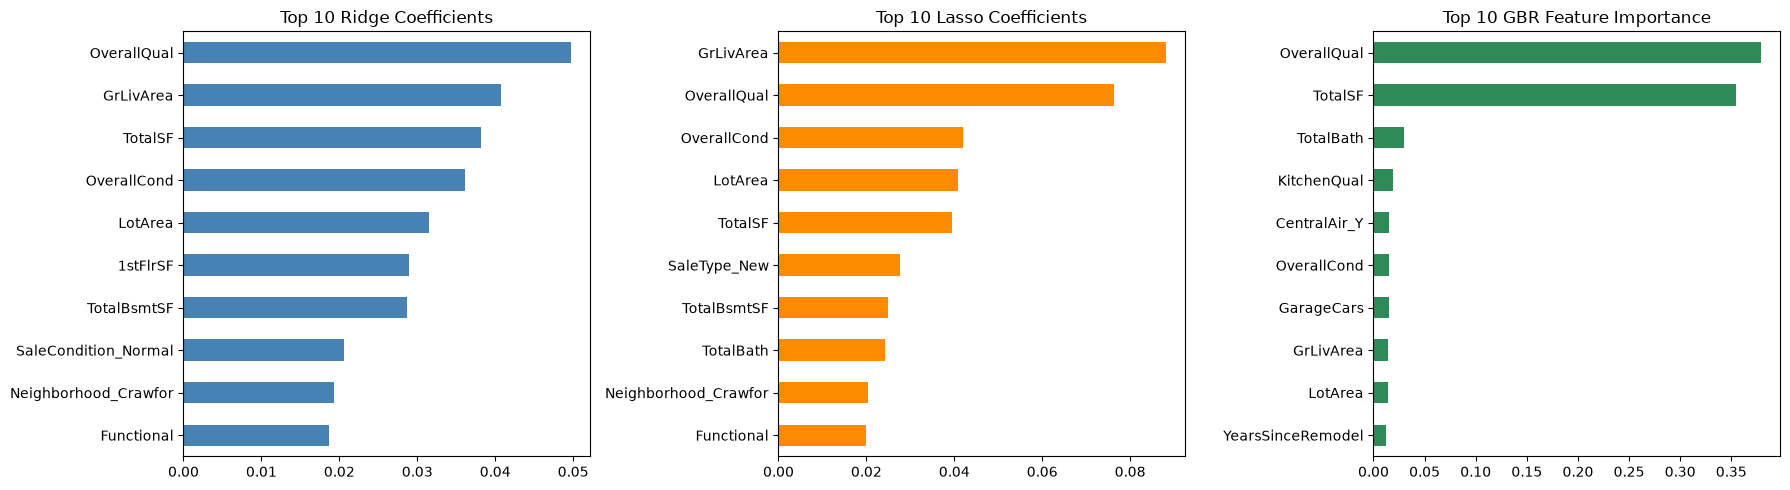

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ridge_coefs.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Ridge Coefficients')
axes[0].invert_yaxis()

lasso_coefs.head(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Lasso Coefficients')
axes[1].invert_yaxis()

gbr_importance.head(10).plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Top 10 GBR Feature Importance')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../app/feature_importance.png', dpi=150)
plt.show()